<a href="https://colab.research.google.com/github/sathar1919/Data-Science-Projects/blob/main/classify_an_image_of_fashion_items_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 24.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.25.1 requires protobuf!=5.28.0,!=5.29.0,<7,>4.21.0, but you have protobuf 7.34.1 which is incompat

In [1]:
#import tensor flow
import tensorflow as tf
#print version
print(tf.__version__)

2.21.0


In [6]:
#import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input,Conv2D, Dense,Flatten, Dropout, MaxPool2D
from tensorflow.keras.models import Model


In [7]:
#downloads the Fashion MNIST dataset that contains images of different fashion items along with their labels.
mnist_data = tf.keras.datasets.fashion_mnist


In [8]:
#script divides the data into training images and training labels and test images and test labels.
(training_images, training_labels), (test_images, test_labels) = mnist_data .load_data()

In [9]:
#Images in our dataset are greyscale images where each pixel value lies between 0 and 255.
#The following script normalizes pixel values between 0 and 1.
training_images = training_images / 255.0
test_images = test_images / 255.0

In [10]:
#print the shape of our training data
print(training_images.shape)
#training dataset contains 60 thousand records (images).
#Each image is 28 pixels wide and 28 pixels high

(60000, 28, 28)


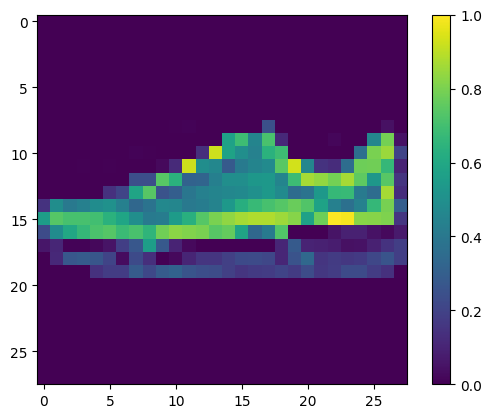

In [11]:
#print an image randomly from the test set
plt.figure()
plt.imshow(test_images[9])
plt.colorbar()
plt.grid(False)
plt.show()
#output shows that the 9th image in our test set is the image of a sneaker.

In [12]:
#next step is to change the dimensions of our input images.
#CNN in Keras expect data to be in the format Width- Height-Channels.
#Our images contain width and height but no channels.
#Since the images are grayscale, we set the image channel to 1, as shown in the following script:
training_images = np.expand_dims(training_images, -1)
test_images = np.expand_dims(test_images, -1)
print(training_images.shape)

(60000, 28, 28, 1)


In [14]:
#next step is to find the number of output classes.
#This number will be used to define the number of neurons in the output layer.
output_classes = len(set(training_labels))
print("Number of output classes is: ", output_classes)

Number of output classes is:  10


In [15]:
#print the shape of a single image in the training set
training_images[0].shape

(28, 28, 1)

In [20]:
#script creates a model for our convolutional neural network
input_layer = Input(shape = training_images[0].shape )
conv1 = Conv2D(32, (3,3), strides = 2, activation= 'relu')(input_layer)
maxpool1 = MaxPool2D(2, 2)(conv1)
conv2 = Conv2D(64, (3,3), strides = 2, activation= 'relu')(maxpool1)
flat1 = Flatten()(conv2)
drop1 = Dropout(0.2)(flat1)
dense1 = Dense(512, activation = 'relu')(drop1)
drop2 = Dropout(0.2)(dense1)
output_layer = Dense(output_classes, activation= 'softmax')(drop2)
model = Model(input_layer, output_layer)

The model contains one input layer, two convolutional layers, one flattening layer,
one hidden dense layer, and one output layer. The number of filters in the first
convolutional layer is 32, while the second convolutional layer is 64. The kernel
size for both convolutional layers is 3 x 3, with a stride of 2. After the first
convolutional layer, a max pooling layer with a size 2 x 2 and stride 2 has also been
defined.


It is important to mention that while defining the model layers, we used Keras
Functional API. With Keras functional API, to connect the previous layer with the
next layer, the name of the previous layer is passed inside the parenthesis at the end
of the next layer.

In [21]:
#compiles the model
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

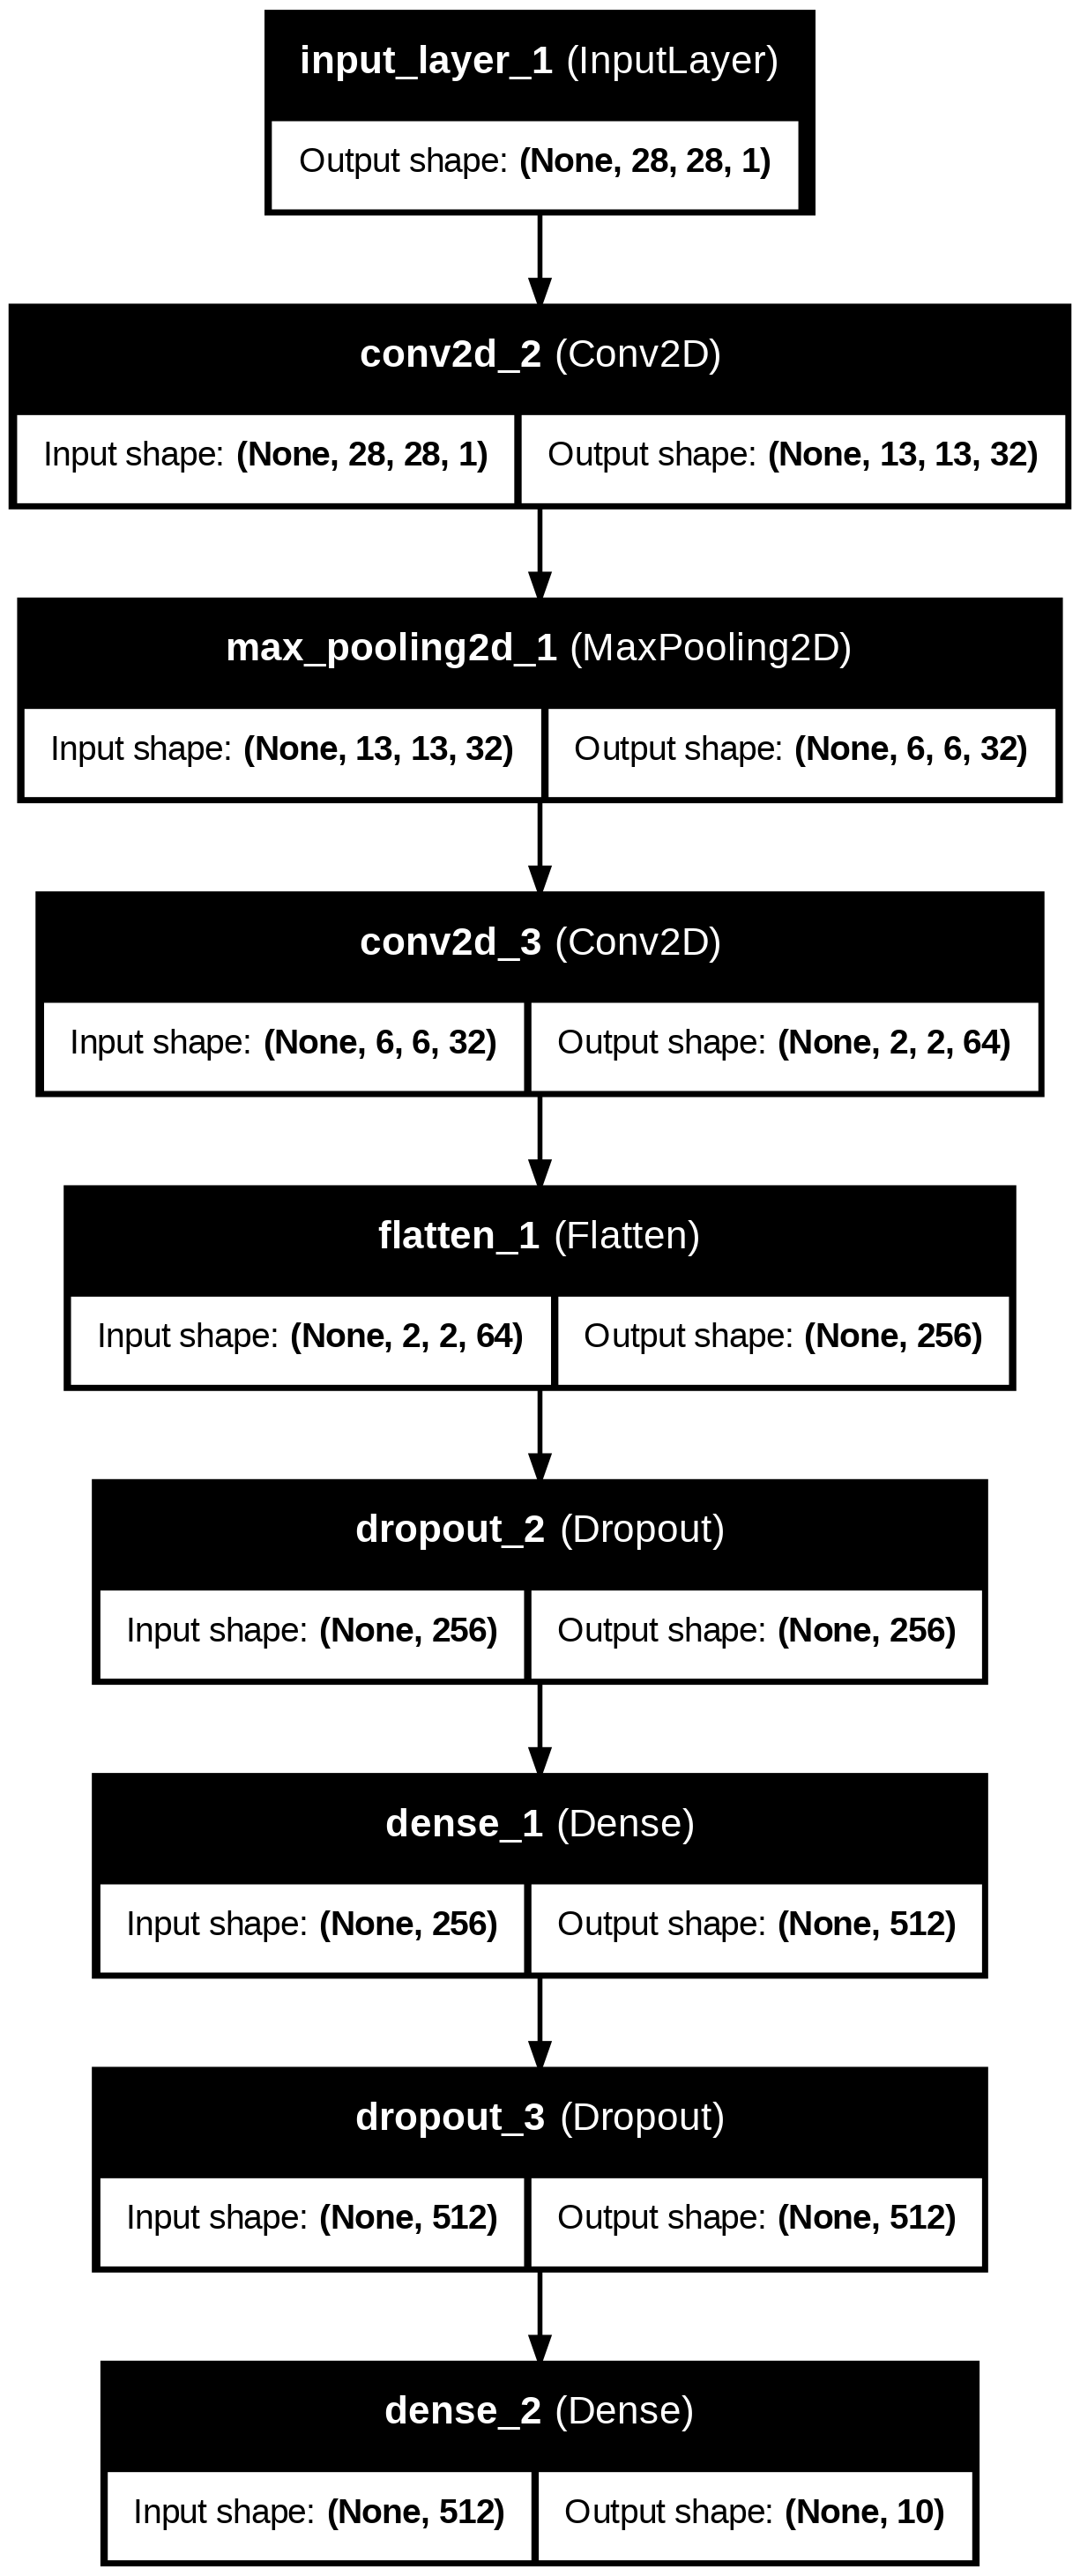

In [23]:
#script to print the model architecture
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot1.png', show_shapes=True, show_layer_names=True)

In [24]:
#trains the image classification mode
model_history = model.fit(training_images, training_labels, epochs=20, validation_data=(test_images,test_labels), verbose=1)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7811 - loss: 0.5954 - val_accuracy: 0.8359 - val_loss: 0.4487
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8400 - loss: 0.4317 - val_accuracy: 0.8532 - val_loss: 0.3990
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8565 - loss: 0.3883 - val_accuracy: 0.8667 - val_loss: 0.3671
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8658 - loss: 0.3598 - val_accuracy: 0.8685 - val_loss: 0.3618
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8740 - loss: 0.3382 - val_accuracy: 0.8743 - val_loss: 0.3401
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8795 - loss: 0.3229 - val_accuracy: 0.8766 - val_loss: 0.3350
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8852 - loss: 0.3100 - val_accuracy: 0.8798 - val_loss: 0.3306
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8865 - loss: 0.2975 -

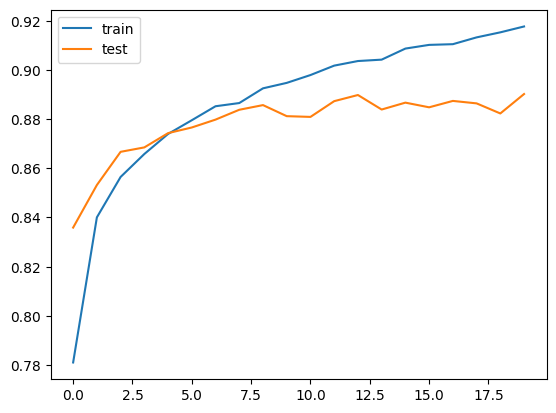

In [27]:
#plot the training and test accuracies for our model
import matplotlib.pyplot as plt
plt.plot(model_history.history['accuracy'], label = 'accuracy')
plt.plot(model_history.history['val_accuracy'], label = 'val_accuracy')
plt.legend(['train','test'], loc='upper left')

output shows that training accuracy is higher, and test accuracy starts to flatten after 88 percent.

We can say that our model is overfitting.

In [28]:
#make a prediction on one of the images in the test set.
#Let’s predict the label for image 9.
#We know that image 9 contains a sneaker, as we saw earlier by plotting the image
output = model.predict(test_images)
prediction = np.argmax(output[9])
print(prediction)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
7


output shows number 7. The output will always be a number since deep
learning algorithms work only with numbers. The numbers correspond to the following labels.

0: T-shirt\top

1: Trouser

2: Pullover

3: Dress

4: Coat

5: Sandal

6: Shirt

7: Sneaker

8: Bag

9: Ankle boot

The above list shows that number 7 corresponds to sneakers. Hence, the prediction by our CNN is correct.

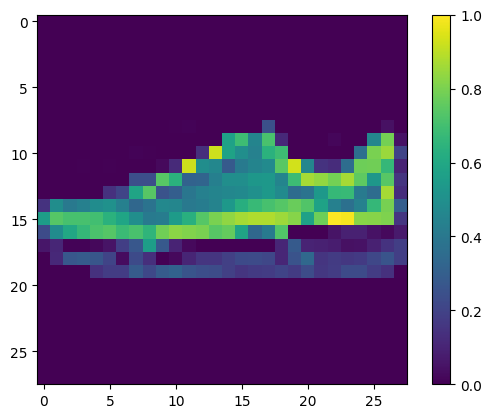

In [30]:
plt.figure()
plt.imshow(test_images[9])
plt.colorbar()
plt.grid(False)
plt.show()

In [38]:
# 1. Initialize Git (if not already done)
# This creates a new Git repository in your current working directory.
# Run this only once per project.
!git init

Reinitialized existing Git repository in /content/.git/


In [54]:
# 2. Configure your Git identity
# Replace with your GitHub username and email
!git config --global user.name "sathar1919"
!git config --global user.email "sathar192019@gmail.com"

In [41]:
# 3. Save your notebook
# It's crucial to save your notebook first (File > Save) so the .ipynb file is up-to-date.

In [42]:
# 4. Add your notebook and other relevant files
# The '.' adds all changes in the current directory
# If you only want to add specific files, replace '.' with the file names, e.g., 'your_notebook_name.ipynb'
!git add .

In [43]:
# 5. Commit your changes
# The message after -m should be a brief description of your changes.
!git commit -m "Initial commit of the Fashion MNIST CNN notebook"

On branch master
nothing to commit, working tree clean


In [51]:
# 6. Add a remote repository
# Replace <YOUR_GITHUB_USERNAME> and <YOUR_REPO_NAME> with your actual GitHub username and repository name.
# Make sure you have created an empty repository on GitHub first.
!git remote rm origin || true # Remove existing remote if it exists
!git remote add origin https://github.com/sathar1919/Data-Science-Projects.git

### Important Note on Authentication:

When you run the `git push` command, Git will ask for your GitHub username and password/Personal Access Token (PAT).

**GitHub no longer supports password authentication for Git operations.** You must use a Personal Access Token (PAT).

1.  **Generate a PAT:** Go to your GitHub settings -> Developer settings -> Personal access tokens -> Tokens (classic) -> Generate new token. Give it a descriptive name and select the `repo` scope. Copy the generated token immediately as you won't see it again.
2.  When prompted for a password during `git push`, enter your PAT.

In [53]:
# 7. Push your commits to GitHub
# The -u flag sets the upstream, so subsequent pushes can just be `git push`
# Replace <YOUR_PERSONAL_ACCESS_TOKEN> with your actual token.
!git push https://<YOUR_PERSONAL_ACCESS_TOKEN>@github.com/sathar1919/Data-Science-Projects.git master

/bin/bash: line 1: YOUR_PERSONAL_ACCESS_TOKEN: No such file or directory
